**Taller 2 - Efecto de los datos en la generación de modelos**

Diego Andrés Burbano A.


## 1. Importar librerias necesarias para el modelo

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from imblearn.over_sampling import SMOTE
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier

import os
from google.colab import drive

## 2. Carga de datos

In [15]:
# En esta celda se esta montando el drive  que tiene almacenado los datos en la ruta MyDrive/datos
drive.mount('/content/drive', force_remount=True)

# una vez se montó el drive, se cambia la ruta de archivo de 'content' de Colab por la ruta de Google Drive ('/MyDrive/datos/')
os.chdir('/content/drive/MyDrive/datos/')

Mounted at /content/drive


Revisión preliminar de datos

In [16]:
data = pd.read_csv('./Heart_Failure_Details.csv', sep=',')
data.head()

,age,anaemia,creatinine phosphokinase,diabetes,ejection fraction,high bp,platelets,serum creatinine,serum sodium,sex,smoking,death
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,1


In [17]:
#Cantidad y dimensionalidad de los datos
data.shape

(299, 12)

In [18]:
#Perfilamiento de los datos
data.describe()

,age,anaemia,creatinine phosphokinase,diabetes,ejection fraction,high bp,platelets,serum creatinine,serum sodium,sex,smoking,death
count,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.00000,299.000000,299.000000,299.00000,299.00000
mean,60.833893,0.431438,581.839465,0.418060,38.083612,0.351171,263358.029264,1.39388,136.625418,0.648829,0.32107,0.32107
std,11.894809,0.496107,970.287881,0.494067,11.834841,0.478136,97804.236869,1.03451,4.412477,0.478136,0.46767,0.46767
min,40.000000,0.000000,23.000000,0.000000,14.000000,0.000000,25100.000000,0.50000,113.000000,0.000000,0.00000,0.00000
25%,51.000000,0.000000,116.500000,0.000000,30.000000,0.000000,212500.000000,0.90000,134.000000,0.000000,0.00000,0.00000
50%,60.000000,0.000000,250.000000,0.000000,38.000000,0.000000,262000.000000,1.10000,137.000000,1.000000,0.00000,0.00000
75%,70.000000,1.000000,582.000000,1.000000,45.000000,1.000000,303500.000000,1.40000,140.000000,1.000000,1.00000,1.00000
max,95.000000,1.000000,7861.000000,1.000000,80.000000,1.000000,850000.000000,9.40000,148.000000,1.000000,1.00000,1.00000


In [19]:
#Revisión de datos faltantes
print(f'Datos nulos: \n {data.isna().sum()}')

Datos nulos: 
 age                         0
anaemia                     0
creatinine phosphokinase    0
diabetes                    0
ejection fraction           0
high bp                     0
platelets                   0
serum creatinine            0
serum sodium                0
sex                         0
smoking                     0
death                       0
dtype: int64


No existen datos faltantes o nulos.

In [20]:
#Identificación de datos repetidos
print(f'Datos duplicados: {data.duplicated().sum()}')

Datos duplicados: 0


No existen datos duplicados o repetidos.

Visualización de los datos contenidos en el dataset:

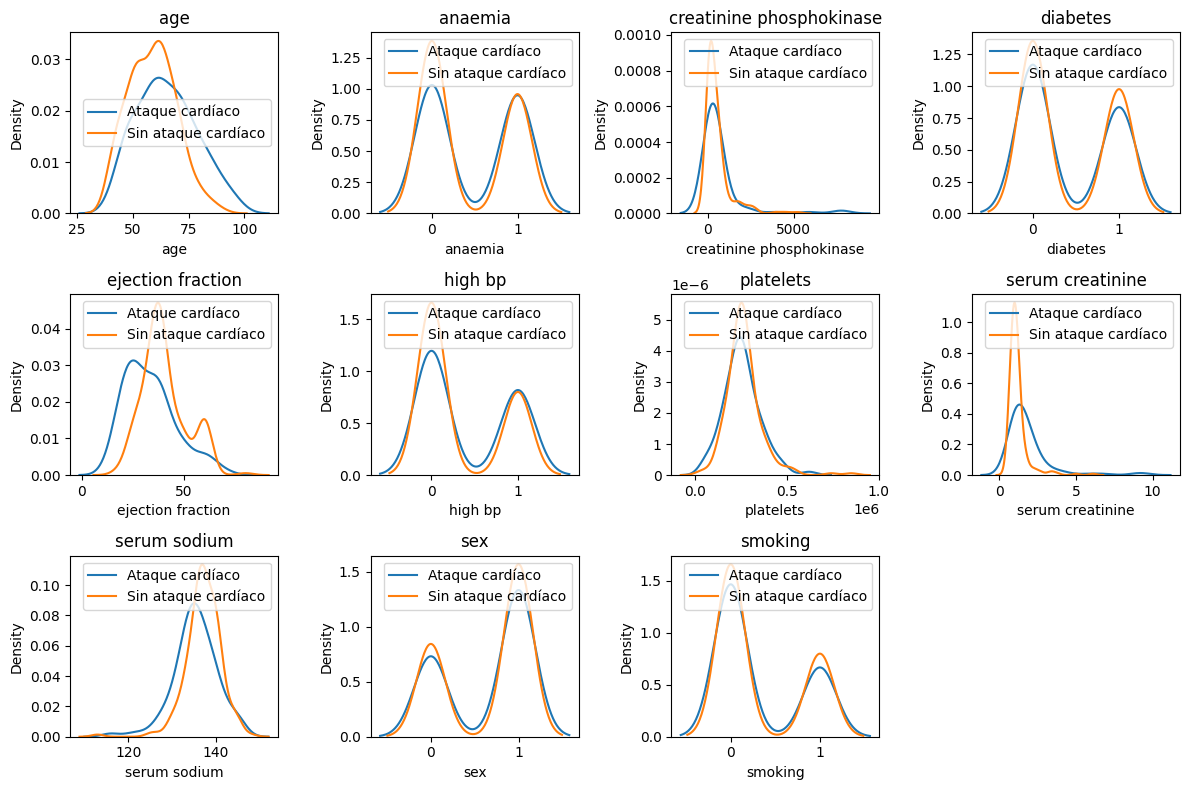

In [21]:
heart_attack = data[data['death'] == 1]
no_heart_attack = data[data['death'] == 0]

heart_attack = data[data['death'] == 1]
no_heart_attack = data[data['death'] == 0]

plt.figure(figsize=(12, 8))
for feature in data.columns[:-1]:
    plt.subplot(3, 4, data.columns.get_loc(feature) + 1)

    sns.kdeplot(heart_attack[feature], label='Ataque cardíaco', fill=False)
    sns.kdeplot(no_heart_attack[feature], label='Sin ataque cardíaco', fill=False)

    plt.legend()
    plt.title(feature)

plt.tight_layout()
plt.show()


##3. Preparación de los sets de entrenamiento

In [22]:
# Dividir los datos (X) y variable objetivo (y)
X = data.drop('death', axis=1)
y = data['death']

# Dividir los datos en conjuntos de entrenamiento y prueba
#Set #1 (80% entrenamiento / 20% prueba)
X_train11, X_test11, y_train11, y_test11 = train_test_split(X, y, test_size= 0.2, random_state=42)
#Set #2 (50% entrenamiento / 50% prueba)
X_train12, X_test12, y_train12, y_test12 = train_test_split(X, y, test_size= 0.5, random_state=42)
#Set #3 (20% entrenamiento / 80% prueba)
X_train13, X_test13, y_train13, y_test13 = train_test_split(X, y, test_size= 0.8, random_state=42)

## 4. Creacion del modelo de clasificación y revisión de resultados

In [23]:
# Creación del modelo
model = DecisionTreeClassifier()

#Entrenamiento del modelo
model.fit(X_train11, y_train11)

DecisionTreeClassifier()

Precisión de Árbol de Decisión para el set # 1: 0.7


<Axes: >

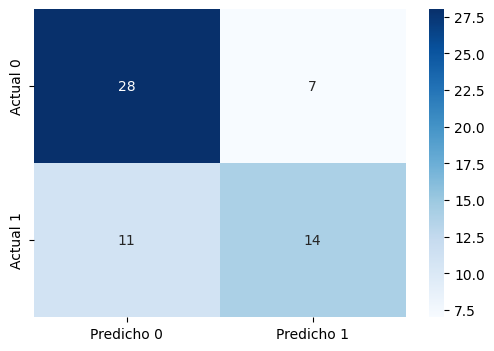

In [24]:
#Predicciones con el conjunto de prueba para el set # 1
y_pred11 = model.predict(X_test11)

#Métricas de desempeño
accuracy11 = accuracy_score(y_test11, y_pred11)
print("Precisión de Árbol de Decisión para el set # 1:", accuracy11)

cm11 = confusion_matrix(y_test11, y_pred11)
cm_df11 = pd.DataFrame(cm11, index=['Actual 0', 'Actual 1'], columns=['Predicho 0', 'Predicho 1'])
plt.figure(figsize=(6, 4))
sns.heatmap(cm_df11, annot=True, cmap='Blues', fmt='g')

Se entrenará el modelo con el set de datos # 2:

Precisión de Árbol de Decisión para el set # 2: 0.6533333333333333


<Axes: >

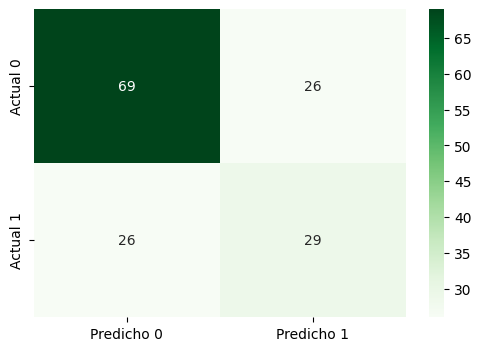

In [25]:
# Creación del modelo # 2
model = DecisionTreeClassifier()

#Entrenamiento del modelo # 2
model.fit(X_train12, y_train12)

#Predicciones con el conjunto de prueba # 2
y_pred12 = model.predict(X_test12)

#Métricas de desempeño
accuracy12 = accuracy_score(y_test12, y_pred12)
print("Precisión de Árbol de Decisión para el set # 2:", accuracy12)

cm12 = confusion_matrix(y_test12, y_pred12)
cm_df12 = pd.DataFrame(cm12, index=['Actual 0', 'Actual 1'], columns=['Predicho 0', 'Predicho 1'])
plt.figure(figsize=(6, 4))
sns.heatmap(cm_df12, annot=True, cmap='Greens', fmt='g')

In [26]:
assert accuracy12 <0.66, 'Revise el entrenamiento y prueba del modelo'

Se entrena el modelo con el set de datos # 3

Precisión de Árbol de Decisión para el set # 3: 0.6375


<Axes: >

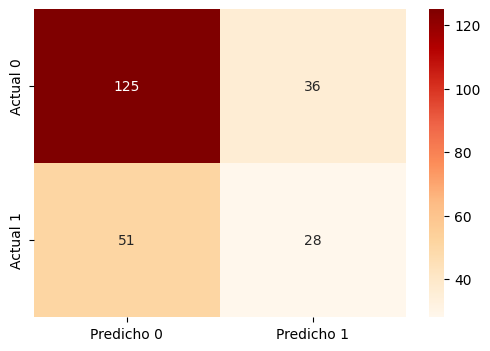

In [27]:
# Creación del modelo # 3
model = DecisionTreeClassifier()

#Entrenamiento del modelo # 3
model.fit(X_train13, y_train13)

#Predicciones con el conjunto de prueba # 3
y_pred13 = model.predict(X_test13)

#Métricas de desempeño
accuracy13 = accuracy_score(y_test13, y_pred13)
print("Precisión de Árbol de Decisión para el set # 3:", accuracy13)

cm13 = confusion_matrix(y_test13, y_pred13)
cm_df13 = pd.DataFrame(cm13, index=['Actual 0', 'Actual 1'], columns=['Predicho 0', 'Predicho 1'])
plt.figure(figsize=(6, 4))
sns.heatmap(cm_df13, annot=True, cmap='OrRd', fmt='g')

In [28]:
assert accuracy13 <0.67, 'Revise el entrenamiento y prueba del modelo'

Revisión del balanceo del set de datos:

death
0    203
1     96
Name: count, dtype: int64


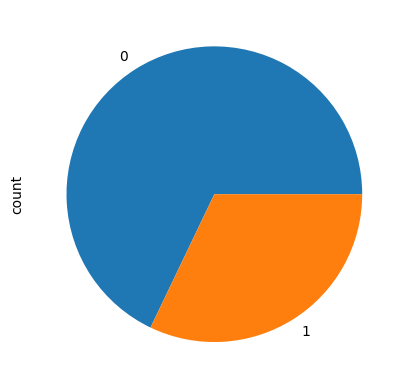

In [29]:
#Conteo para revisar balance de la base de datos
y.value_counts().plot(kind='pie')
print(y.value_counts())

Existe un desbalance de clases, se procede a balancear los datos para evitar que el modelo aprenda sobre un set sesgado y por lo tanto mejore su precisión:

death
1    203
0    203
Name: count, dtype: int64


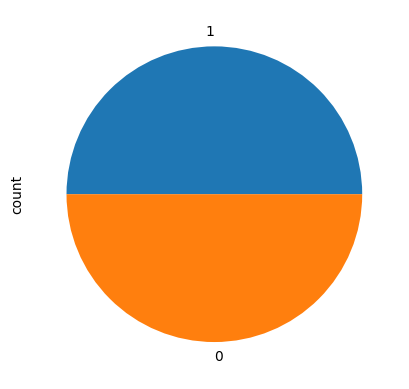

In [30]:
#Balanceo de datos empleando oversampling
smote = SMOTE(random_state=42)
X_train_over, y_train_over = smote.fit_resample(X, y)

#Visualización de la proporción de clases en los datos de entrenamiento
y_train_over.value_counts().plot(kind='pie')
print(y_train_over.value_counts())

Se generarán los tres set de datos a partir del nuevo dataset balanceado

In [31]:
# Dividir los datos en conjuntos de entrenamiento y prueba
#Set #1 (80% de datos para entrenamiento / 20% de datos de prueba)
X_train21, X_test21, y_train21, y_test21 = train_test_split(X_train_over, y_train_over, test_size=0.2, random_state=42)

#Set #2 (50% de datos para entrenamiento / 50% de datos de prueba)
X_train22, X_test22, y_train22, y_test22 = train_test_split(X_train_over, y_train_over, test_size=0.5, random_state=42)

#Set #1 (20% de datos para entrenamiento / 80% de datos de prueba)
X_train23, X_test23, y_train23, y_test23 = train_test_split(X_train_over, y_train_over, test_size=0.8, random_state=42)

Creación del modelo con los datos del set # 1

Precisión de Árbol de Decisión para el set # 1 balanceado: 0.7560975609756098


<Axes: >

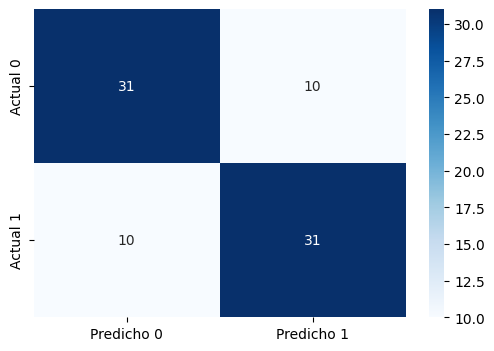

In [32]:
# Creación del modelo # 1
model = DecisionTreeClassifier()

#Entrenamiento del modelo # 1
model.fit(X_train21, y_train21)

#Predicciones con el conjunto de prueba
y_pred21 = model.predict(X_test21)

#Métricas de desempeño del modelo # 1
accuracy21 = accuracy_score(y_test21, y_pred21)
print("Precisión de Árbol de Decisión para el set # 1 balanceado:", accuracy21)

cm21 = confusion_matrix(y_test21, y_pred21)
cm_df21 = pd.DataFrame(cm21, index=['Actual 0', 'Actual 1'], columns=['Predicho 0', 'Predicho 1'])
plt.figure(figsize=(6, 4))
sns.heatmap(cm_df21, annot=True, cmap='Blues', fmt='g')

In [33]:
assert accuracy21 <0.82, 'Revise el entrenamiento y prueba del modelo'

Creación del modelo con los datos del set # 2

Precisión de Árbol de Decisión para el set # 2 balanceado: 0.7438423645320197


<Axes: >

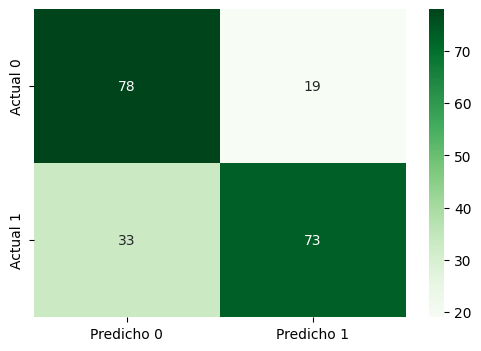

In [34]:
# Creación del modelo # 2
model = DecisionTreeClassifier()

#Entrenamiento del modelo # 2
model.fit(X_train22, y_train22)

#Predicciones con el conjunto de prueba
y_pred22 = model.predict(X_test22)

#Métricas de desempeño del modelo # 2
accuracy22 = accuracy_score(y_test22, y_pred22)
print("Precisión de Árbol de Decisión para el set # 2 balanceado:", accuracy22)

cm22 = confusion_matrix(y_test22, y_pred22)
cm_df22 = pd.DataFrame(cm22, index=['Actual 0', 'Actual 1'], columns=['Predicho 0', 'Predicho 1'])
plt.figure(figsize=(6, 4))
sns.heatmap(cm_df22, annot=True, cmap='Greens', fmt='g')

In [35]:
assert accuracy22 <0.79, 'Revise el entrenamiento y prueba del modelo'

Creación del modelo con los datos del set # 3

Precisión de Árbol de Decisión para el set # 3 balanceado: 0.6030769230769231


<Axes: >

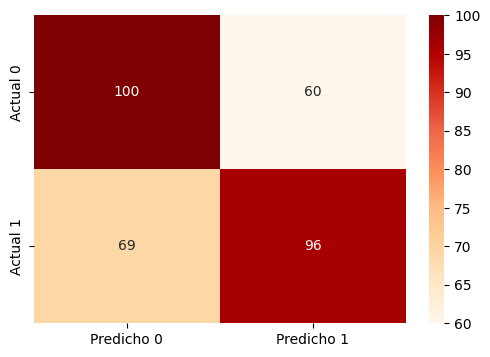

In [36]:
# Creación del modelo # 3
model = DecisionTreeClassifier()

#Entrenamiento del modelo # 3
model.fit(X_train23, y_train23)

#Predicciones con el conjunto de prueba
y_pred23 = model.predict(X_test23)

#Métricas de desempeño del modelo # 2
accuracy23 = accuracy_score(y_test23, y_pred23)
print("Precisión de Árbol de Decisión para el set # 3 balanceado:", accuracy23)

cm23 = confusion_matrix(y_test23, y_pred23)
cm_df23 = pd.DataFrame(cm23, index=['Actual 0', 'Actual 1'], columns=['Predicho 0', 'Predicho 1'])
plt.figure(figsize=(6, 4))
sns.heatmap(cm_df23, annot=True, cmap='OrRd', fmt='g')

In [37]:
assert accuracy23 <0.65, 'Revise el entrenamiento y prueba del modelo'

##5. Preguntas de análisis

¿El desempeño de los modelos es significativamente diferente? Comente a partir
de los resultados de la matriz de confusión.

¿Cómo se afecta el desempeño del modelo al ser entrenado con diferentes proporciones de datos de entrenamiento y prueba?

¿Cómo cambia el desempeño del modelo al ser entrenado antes y después de balancear la base de datos? Comente como esto podría afectar la implementación de este modelo en el cotexto médico del caso aplicado

**Respuesta:**


Tabla comparativa de resultados:

In [38]:
#Se genera una tabla comparativa con los resultados de los modelos balanceados y desbalanceados
tabla = pd.DataFrame(
    {
        "80% - 20%": [accuracy11, accuracy21],
        "50% - 50%": [accuracy12, accuracy22],
        "20% - 80%": [accuracy13, accuracy23],
    },
    index=["Set desbalanceado (299 registros)", "Set balanceado (406 registros)"]
)

print(tabla)

                                   80% - 20%  50% - 50%  20% - 80%
Set desbalanceado (299 registros)   0.700000   0.653333   0.637500
Set balanceado (406 registros)      0.756098   0.743842   0.603077


En la medida que contamos con menos datos para entrenar los modelos vemos que la precisión (accuracy) del modelo decrece, ya que el modelo cuenta con menos datos de entrenamiento para aprender. Por ende, en la medida que contemos con mas datos en nuestro set vamos a contar con un mayor desempeño.

Para el caso de los modelos desbalanceados, el cual cuenta con 299 elementos, el decrecimiento de su accuracy cayo en 8.9% (decreciendo entre 70% al 63%). Para el caso de los modelos balanceados, con 406 elementos en el set de datos, la caida en el desempeño es mayor y corresponde a un 20% (decreciendo entre 75% y 60%).  

Este comportamiento se puede explicar ya que en el set desbalanceado el modelo da sus resultados apoyado en la clase mayoritaria, lo que lo hace mas estable aunque menos justo, en cambio en el modelo balanceado, éste pierde capacidad de generalización y sufre una caida mayor en el accuracy.

Al contar con un set de datos balanceado su accuracy se incrementa en un 8%,  al pasar de un 70% a un 75% para el caso de un set 80% train -20% test. Esto se debe a que ahora contamos con mas datos representativos de la clase 1, los cuales en el modelo desbalanceado.  

Si bien este incremento, en apariencia es bueno, debemos tener en cuenta que estamos creando un modelo para aplicaciones médicas. En general lo que hicimos fue a partir de un set de datos pequeño, hacer imputaciones sobre la clase menor, que en este caso corresponde a pacientes fallecidos. Al aplicar SMOTE estamos generando nuevos casos de pacientes fallecidos que no son reales, sino que se trata de aproximaciones sobre un set de datos reducido. Por lo tanto, si bien como resultado tenemos un modelo mas equilibrado, en realidad estamos entrenando sobre datos sintéticos que no necesariamente representan la realidad clínica.

El riesgo ocurre cuando tratamos de generalizar el modelo, utilizando  pacientes reales, ya que podriamos estar subestimando o sobreestimando la mortalidad, lo cual trae consecuencias serías en el contexto en el cual el modelo estaría corriendo. Por lo tanto, la técnica de oversampling para este caso en particular (considerando la aplicación y el número de datos) puede ayudar a nivel experimental pero no garantiza los resultados en ambientes clínicos productivos, por lo tanto debe considerarse con cautela.

En aplicaciones médicas críticas, los falsos negativos representan un riesgo mayor que los falsos positivos, por lo cual la validación del modelo no debe limitarse al accuracy, sino priorizar la detección de la clase minoritaria.

La recomendación sería apoyarse en el juicio de expertos, utilizar métricas complementarias como recall, F1-score, entre otras y alentar el re-entrenamiento del modelo con un mayor volumen de datos antes de proponer que el mismo sea puesto en producción.





